# Simulating, evolving and measuring chemistries

Every chemistry in Chemart is one of three types
(`describe_chemistry(id)["type"]`):

- **given**: the chemistry *is* a reaction network, written down. Simulating
  it means integrating its rate equations, or sampling a stochastic path.
- **generator**: an algorithm computes the network from its arguments; the
  network is then simulated like a given one.
- **gas**: a Turing gas. Its molecules are structures that react by a
  procedure, so the network is not known in advance: running the chemistry
  *evolves* a soup, and the network is the record of what happened.

This notebook simulates a given network (the Brusselator) with
`chemart.simulate`, evolves two gases (the prime-number chemistry and
AlChemy) with `chemart.evolve`, and compares networks of all three types
with `chemart.measure`.

In [1]:
import chemart
import matplotlib.pyplot as plt
from chemart import measures, simulate

## 1. A given network: the Brusselator

Four reactions and six species. `A` and `B` are held constant (buffered),
`X` and `Y` are the dynamic species, and `D` and `E` collect waste.

In [2]:
print(chemart.describe_chemistry("brusselator")["type"])

net = chemart.generate_network("brusselator", seed=1)
print(net.to_text())
print("buffered:", net.extras["buffered"])
print("initial state:", net.initial_state)

given
A -> X  [mass-action k=1.0]
B + X -> Y + D  [mass-action k=1.0]
2 X + Y -> 3 X  [mass-action k=1.0]
X -> E  [mass-action k=1.0]
buffered: ['A', 'B']
initial state: {'A': 1.0, 'B': 3.0, 'X': 0.0, 'Y': 0.0, 'D': 0.0, 'E': 0.0}


The record carries everything the rate equations need: the stoichiometry,
a mass-action constant on every reaction, the initial state and the buffered
species. `simulate.ode` integrates them and returns a `Trajectory`, whose
`array` gives the time points and the amounts as arrays.

The Brusselator oscillates when `b > 1 + a²`. With `a = 1`, that means
`b > 2`: below it, `X` and `Y` settle to a fixed point; above it, they
circle a limit cycle.

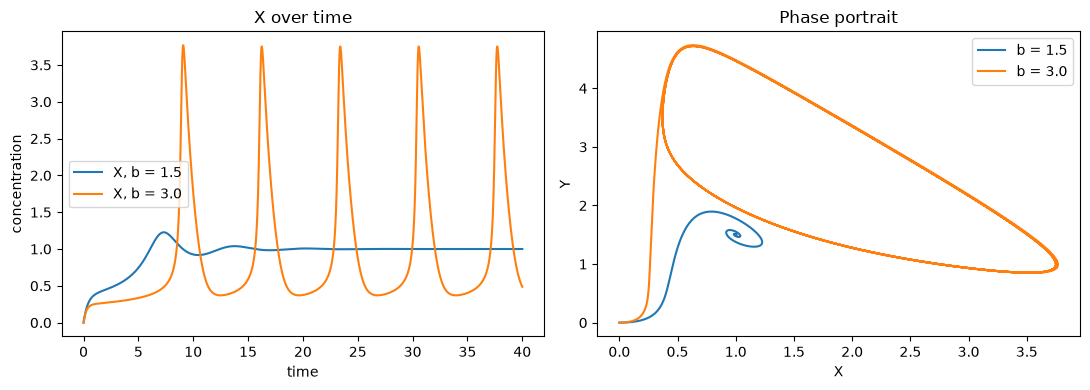

In [3]:
fig, (ax_t, ax_phase) = plt.subplots(1, 2, figsize=(11, 4))
for b in (1.5, 3.0):
    traj = simulate.ode(chemart.generate_network("brusselator", seed=1, b=b), t_end=40, points=2000)
    ids, t, x = traj.array(["X", "Y"])
    ax_t.plot(t, x[:, 0], label=f"X, b = {b}")
    ax_phase.plot(x[:, 0], x[:, 1], label=f"b = {b}")

ax_t.set(xlabel="time", ylabel="concentration", title="X over time")
ax_phase.set(xlabel="X", ylabel="Y", title="Phase portrait")
ax_t.legend(); ax_phase.legend()
plt.tight_layout()

`simulate.ssa` samples one stochastic path of the same network with
Gillespie's algorithm. Amounts are per unit volume, so `volume` sets the
number of molecules: a small volume gives a noisy cycle, a large one
approaches the rate equations.

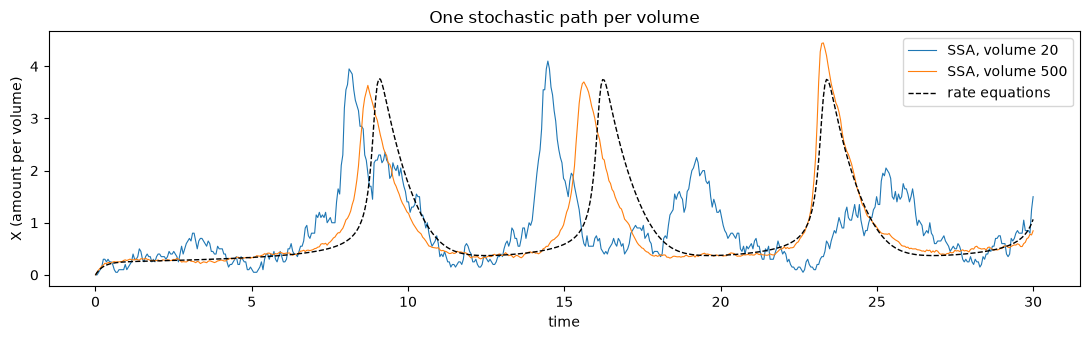

In [4]:
net = chemart.generate_network("brusselator", seed=1, b=3.0)
fig, ax = plt.subplots(figsize=(11, 3.5))
for volume in (20, 500):
    path = simulate.ssa(net, t_end=30, volume=volume, seed=1, points=600)
    ids, t, x = path.array(["X"])
    ax.plot(t, x[:, 0], lw=0.8, label=f"SSA, volume {volume}")
ids, t, x = simulate.ode(net, t_end=30, points=600).array(["X"])
ax.plot(t, x[:, 0], "k--", lw=1, label="rate equations")
ax.set(xlabel="time", ylabel="X (amount per volume)", title="One stochastic path per volume")
ax.legend()
plt.tight_layout()

A network without its own rates or initial state (a generator such as
Kauffman's autocatalytic sets) gets them from `rates=` and `x0=`: a number, a
table, a file or a distribution drawn with the call's seed. `simulate`
refuses clearly when something is missing, rather than returning a flat line.

## 2. A gas: the prime-number chemistry

Here the molecules are integers. When a smaller number divides a larger one,
the larger is replaced by the quotient: `4 + 12 -> 4 + 3`. No network is
written down in advance: the chemistry fills a well-stirred soup with random
numbers and lets them collide. `chemart.evolve` runs that process and
returns a `Trajectory` in the chemistry's own clock, here collisions.

In [5]:
info = chemart.describe_chemistry("prime-number-chemistry")
print(info["type"], info["faces"], info["clock"])

traj = chemart.evolve("prime-number-chemistry", seed=1)
print(len(traj.frames), "frames up to", traj.times()[-1], traj.clock)
print(traj.network.summary())

gas ['generate', 'evolve'] collisions
101 frames up to 10000.0 collisions
prime-number-chemistry: 201 species, 159 reactions, status=observed
provides: catalysts, initial-state, stoichiometry, topology
seed: 1
extras: analysis, final_state, primes


Each frame holds the soup at that moment (`frame.state`), the reactions fired
since the previous frame (`frame.fired`) and the chemistry's own observables.
This one reports the fraction of primes, and shows the chemistry's known
result: composite numbers keep being divided away, so the soup turns prime.
Different seeds are different runs:

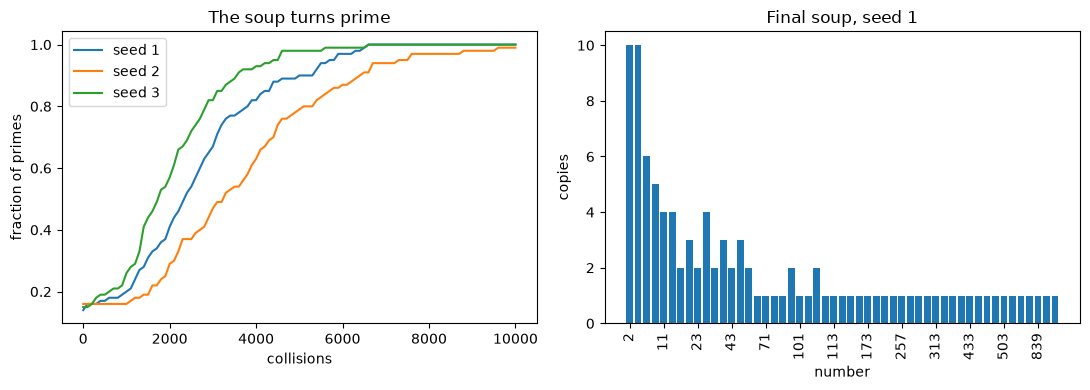

In [6]:
fig, (ax_frac, ax_pop) = plt.subplots(1, 2, figsize=(11, 4))
for seed in (1, 2, 3):
    run = chemart.evolve("prime-number-chemistry", seed=seed)
    ax_frac.plot(run.times(), run.series("prime_fraction"), label=f"seed {seed}")

final = traj.frames[-1].state                      # seed 1: what the soup holds at the end
numbers = sorted((int(s[1:]), n) for s, n in final.items() if n > 0)
ax_pop.bar(range(len(numbers)), [n for _, n in numbers])
ax_pop.set_xticks(range(0, len(numbers), 4), [numbers[i][0] for i in range(0, len(numbers), 4)], rotation=90)

ax_frac.set(xlabel="collisions", ylabel="fraction of primes", title="The soup turns prime")
ax_pop.set(xlabel="number", ylabel="copies", title="Final soup, seed 1")
ax_frac.legend()
plt.tight_layout()

The network of a gas is the record of what fired (`status == "observed"`),
each reaction with how often it fired. Another seed gives another network.

In [7]:
for r in sorted(traj.network.reactions, key=lambda r: -(r.count or 0))[:6]:
    print(f"{r.count:3d} x  {r.to_text().split('  (x')[0]}")

  6 x  n9 + n3 -> 2 n3
  4 x  n4 + n2 -> 2 n2
  2 x  n26 + n2 -> n2 + n13
  2 x  n33 + n3 -> n3 + n11
  2 x  n3 + n6 -> n3 + n2
  2 x  n2 + n94 -> n2 + n47


## 3. Measures in evolutionary time: AlChemy

AlChemy's molecules are λ-terms, and a collision applies one to the other.
`measures.over` applies measures frame by frame: population measures
(richness, Shannon diversity) read each frame's soup, and network measures
read the network of the reactions fired in the last `window` frames.

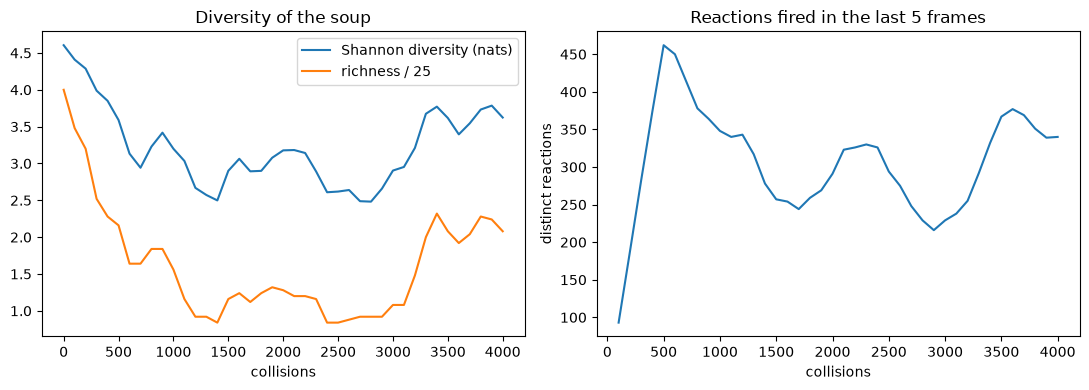

In [8]:
traj = chemart.evolve("alchemy", seed=1, collisions=4000)
series = measures.over(traj, ["richness", "shannon", "n_reactions"], window=5)

fig, (ax_div, ax_net) = plt.subplots(1, 2, figsize=(11, 4))
ax_div.plot(series["t"], series["shannon"], label="Shannon diversity (nats)")
ax_div.plot(series["t"], [r / 25 for r in series["richness"]], label="richness / 25")
ax_net.plot(series["t"], series["n_reactions"])
ax_div.set(xlabel=traj.clock, title="Diversity of the soup")
ax_net.set(xlabel=traj.clock, ylabel="distinct reactions", title="Reactions fired in the last 5 frames")
ax_div.legend()
plt.tight_layout()

The same run in the terminal: `chemart evolve alchemy --seed 1 --track shannon`.

## 4. Comparing chemistries by measures

`chemart.measure` computes the registered measures of a network. A measure
that does not apply is left out, not filled in: a RAF needs catalysts and a
food set, so some networks have no `max_raf_fraction`, and
`measures.applicable` says why.

In [9]:
columns = {"n_species": "species", "n_reactions": "reactions", "rank_ratio": "rank ratio",
           "deficiency": "deficiency", "conservation_laws": "cons. laws",
           "degree_gini": "degree Gini", "max_raf_fraction": "maxRAF"}
chemistries = ["brusselator", "michaelis-menten", "repressilator",
               "kauffman-autocatalytic-sets", "raf", "alchemy", "prime-number-chemistry"]

def cell(value):
    if value is None:
        return f"{'-':>12}"
    return f"{value:>12.3f}" if isinstance(value, float) else f"{value:>12}"

print(f"{'chemistry':<28}{'type':<10}" + "".join(f"{label:>12}" for label in columns.values()))
for cid in chemistries:
    values = chemart.measure(chemart.generate_network(cid, seed=1), list(columns))
    kind = chemart.describe_chemistry(cid)["type"]
    print(f"{cid:<28}{kind:<10}" + "".join(cell(values.get(n)) for n in columns))

print()
for cid in ("michaelis-menten", "alchemy"):
    print(cid, measures.applicable(chemart.generate_network(cid, seed=1), ["max_raf_fraction"]))

chemistry                   type           species   reactions  rank ratio  deficiency  cons. laws degree Gini      maxRAF
brusselator                 given                6           4       0.667           0           2       0.300       0.000
michaelis-menten            given                4           3       0.500           0           2       0.194           -
repressilator               given               12          18       0.750           6           3       0.125       0.333


kauffman-autocatalytic-sets generator           62        1608       0.968         683           2       0.375       0.756


raf                         generator          254         746       0.858         155          36       0.472       0.764
alchemy                     gas                 50        1134       1.000        1084           0       0.326           -
prime-number-chemistry      gas                261        1095       0.950         847          13       0.551           -

michaelis-menten {'max_raf_fraction': 'no reaction has a catalyst'}


alchemy {'max_raf_fraction': "no food set (extras['food'], inflow, buffered species or initial state)"}


Many more measures are registered (`measures.describe()` lists them, and
`cost="moderate"` or `"exponential"` adds the dearer ones). Before reading a
graph measure as a property of a chemistry, compare it with its null model
(`measures.zscores`), and remember that a gas's network mixes the chemistry
with how it was sampled.

## The difference in one line

- For a **given** network, Chemart hands you the network and
  `chemart.simulate` runs its dynamics. The network is the same every time.
- For a **generator**, the network changes with the arguments, so its measures
  are studied across them (`measures.sweep`).
- For a **gas**, simulating *is* running the chemistry: `chemart.evolve`
  follows the soup in its own time, and the network comes out of the run.

`chemart.list_chemistries()` lists every chemistry with its `type`.